In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from PIL import Image

In [2]:
def plot_lineplot(file_dict, dataset_name, metric='F1 Score'):
    processed_data = []
    for model_name, file_paths in file_dict.items():
        if not file_paths:
            raise ValueError(f"No file paths provided for model: {model_name}")

        for file_path in file_paths:
            try:
                method_match = re.search(r'_(GP|DAPS)_', file_path, re.IGNORECASE)
                patches_match = re.search(r'(?:in_channels|num_patches)_(\d+)', file_path, re.IGNORECASE)

                if not method_match or not patches_match:
                    raise ValueError(f"File path {file_path} does not match expected format.")

                method = method_match.group(1)
                if method == 'GP':
                    display_method = 'MetImage(GP)'
                elif method == 'DAPS':
                    display_method = 'MSIMG(DAPS)'
                else:
                    raise ValueError(f"Unexpected method found in file path: {file_path}")
                num_patches = int(patches_match.group(1))

                df_summary = pd.read_csv(file_path, index_col='Metric')
                summary_row = df_summary.loc[metric]
                mean_val = summary_row['Mean_Test_on_Holdout']
                ci_lower = summary_row['95% CI Lower']
                ci_upper = summary_row['95% CI Upper']

                processed_data.append({
                    'Model': model_name,
                    'Method': display_method,
                    'Num Patches': num_patches,
                    'Metric': mean_val,
                    'CI Lower': ci_lower,
                    'CI Upper': ci_upper
                })
            except ValueError as e:
                raise ValueError(f"File path {file_path} does not match expected format.")

    if not processed_data:
        raise ValueError("No valid data to plot.")

    df_long = pd.DataFrame(processed_data)

    sns.set_theme(style='whitegrid', font_scale=1.2)
    methods_to_plot = ['MetImage(GP)', 'MSIMG(DAPS)']
    # 'viridis', 'plasma', 'magma', 'cividis', 'Set2', 'Paired', 'tab10'
    colormap_name = 'tab10'
    colors = sns.color_palette(colormap_name, n_colors=2)
    palette = {
        'MetImage(GP)': colors[0],
        'MSIMG(DAPS)': colors[1]
    }
    linestyles = {'MetImage(GP)': '--', 'MSIMG(DAPS)': '-'}
    markers = {'MetImage(GP)': 's', 'MSIMG(DAPS)': 'o'}

    model_order = ['ResNet50', 'DenseNet121', 'EfficientNetB0']
    fig, axes = plt.subplots(1, len(model_order), figsize=(7 * len(model_order), 6))
    for i, model_name in enumerate(model_order):
        ax = axes[i]
        model_data = df_long[df_long['Model'] == model_name]

        for method in methods_to_plot:
            method_data = model_data[model_data['Method'] == method].sort_values('Num Patches')
            if method_data.empty:
                continue
            ax.plot(
                method_data['Num Patches'], method_data['Metric'],
                label=method, color=palette[method], linestyle=linestyles[method],
                marker=markers[method], linewidth=2.5, markersize=8
            )
            ax.fill_between(
                method_data['Num Patches'], method_data['CI Lower'], method_data['CI Upper'],
                color=palette[method], alpha=0.15
            )
        ax.set_title(f'Backbone: {model_name}', fontsize=26, fontweight='bold', pad=10)
        ax.set_xscale('log', base=2)
        ax.set_xticks(sorted(df_long['Num Patches'].unique()))
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, which='both', ls='--', c='0.7')
        ax.set_xlabel('Number of Patches', fontsize=20)
        ax.legend(loc='lower right', fontsize=18)

    axes[0].set_ylabel(metric, fontsize=20)
    plt.tight_layout()

    file_name = f"Comparison of {metric} between MetImage(GP) and MSIMG(DAPS) with a varying number of input patches on the {dataset_name} dataset"
    plt.savefig(f"{file_name}.svg", bbox_inches='tight')
    # plt.savefig(f"{file_name}.tiff", dpi=300, pil_kwargs={'compression': 'tiff_lzw'}, bbox_inches='tight')
    plt.show()

In [ ]:
import os
from collections import defaultdict
dataset_name = 'CD'
file_dict = defaultdict(list)
for model_name in ['ResNet50', 'DenseNet121', 'EfficientNetB0']:
    for method_name in ['GP', 'DAPS']:
        for num_patches in [4, 8, 16, 32, 64]:
            file_path = f"experiment_results/{dataset_name}/{model_name}_{dataset_name}_{method_name}_PATCH_224x224_IN_CHANNELS_{num_patches}_NUM_CLASSES_2_BATCH_SIZE_8/{model_name}_{dataset_name}_num_classes_2_in_channels_{num_patches}_kfold_tested_on_holdout_summary_stats.csv"
            if not os.path.exists(file_path):
                raise ValueError(f"File path {file_path} does not match expected format.")
            file_dict[model_name].append(file_path)
plot_lineplot(file_dict, dataset_name=dataset_name, metric='F1 Score')


In [4]:
def plot_grouped_boxplot(file_dict, dataset_name, metric='F1 Score'):
    processed_data = []
    for model_name, file_paths in file_dict.items():
        if not file_paths:
            raise ValueError(f"File path {file_paths} does not match expected format.")

        for file_path in file_paths:
            try:
                method_match = re.search(r'_(GP|DAPS)_', file_path, re.IGNORECASE)
                patch_size_match = re.search(r'_PATCH_(\d+)x\d+_', file_path, re.IGNORECASE)

                if not method_match or not patch_size_match:
                    raise ValueError(f"File path {file_path} does not match expected format.")

                method = method_match.group(1).upper() # Use .upper() for consistency
                if method == 'GP':
                    display_method = 'MetImage(GP)'
                elif method == 'DAPS':
                    display_method = 'MSIMG(DAPS)'
                else:
                    raise ValueError(f"Unexpected method found in file path: {file_path}")
                patch_size = int(patch_size_match.group(1))

                df_folds = pd.read_csv(file_path)
                for value in df_folds[metric].dropna():
                    processed_data.append({
                        'Model': model_name,
                        'Patch Size': patch_size,
                        'Method': display_method,
                        metric: value
                    })
            except Exception as e:
                raise ValueError(f"Error processing file path {file_path}: {e}")

    if not processed_data:
        raise ValueError("No valid data to plot.")

    df_long = pd.DataFrame(processed_data)

    sns.set_theme(style='whitegrid', font_scale=1.2)
    methods_to_plot = ['MetImage(GP)', 'MSIMG(DAPS)']
    colormap_name = 'tab10'
    colors = sns.color_palette(colormap_name, n_colors=2)
    palette = {
        'MetImage(GP)': colors[0],
        'MSIMG(DAPS)': colors[1]
    }

    model_order = ['ResNet50', 'DenseNet121', 'EfficientNetB0']
    fig, axes = plt.subplots(1, len(model_order), figsize=(8 * len(model_order), 7), sharey=True)

    for i, model_name in enumerate(model_order):
        ax = axes[i]
        model_data = df_long[df_long['Model'] == model_name]

        patch_sizes = sorted(model_data['Patch Size'].unique())
        x_locs = np.arange(len(patch_sizes))

        offset = 0.2
        box_width = 0.35

        for j, method in enumerate(methods_to_plot):
            data_to_plot = [
                model_data[(model_data['Method'] == method) & (model_data['Patch Size'] == p)][metric].values
                for p in patch_sizes
            ]
            positions = x_locs + offset * (j - 0.5) * 2

            bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width, patch_artist=True, manage_ticks=False,
                            showfliers=False)

            for patch in bp['boxes']:
                patch.set_facecolor(palette[method])
                patch.set_alpha(0.7)

            jitter_width = box_width * 0.2

            for k, p_size in enumerate(patch_sizes):
                y_values = data_to_plot[k]
                x_center = positions[k]
                x_jittered = np.random.normal(loc=x_center, scale=jitter_width, size=len(y_values))

                ax.scatter(
                    x_jittered,
                    y_values,
                    color=palette[method],
                    s=100,
                    alpha=0.6,
                    edgecolor='black',
                    linewidth=0.5,
                    zorder=10
                )

        ax.set_title(f"Backbone: {model_name}", fontsize=30, fontweight='bold', pad=10)
        ax.tick_params(axis='y', labelleft=True, labelsize=20)
        ax.set_xticks(x_locs)
        ax.set_xticklabels([f"{p}x{p}" for p in patch_sizes], fontsize=20)
        ax.set_xlabel('Patch Size', fontsize=24)
        # ax.legend(
        #     [
        #     plt.Rectangle((0, 0), 1, 1, facecolor=palette[m], alpha=0.7)
        #     for m in methods_to_plot
        #     ],
        #     methods_to_plot,
        #     loc='lower right',
        #     fontsize=14
        # )
        leg = ax.legend(
            [
            plt.Rectangle((0, 0), 1, 1, facecolor=palette[m], alpha=0.7)
            for m in methods_to_plot
            ],
            methods_to_plot,
            loc='lower right',
            fontsize=24
        )

        leg.set_zorder(20)

    axes[0].set_ylabel(metric, fontsize=24)
    plt.tight_layout()

    file_name = f"Comparison of {metric} between MetImage(GP) and MSIMG(DAPS) with a varying size of input patches on the {dataset_name} dataset"
    plt.savefig(f"{file_name}.svg", bbox_inches='tight')
    plt.show()

In [ ]:
import os
from collections import defaultdict
dataset_name = 'SPNS'
file_dict = defaultdict(list)
for model_name in ['ResNet50', 'DenseNet121', 'EfficientNetB0']:
    for method_name in ['GP', 'DAPS']:
        for patch_size in [32, 64, 128, 224]:
            file_path = f"experiment_results/{dataset_name}/{model_name}_{dataset_name}_{method_name}_PATCH_{patch_size}x{patch_size}_IN_CHANNELS_64_NUM_CLASSES_2_BATCH_SIZE_8/{model_name}_{dataset_name}_num_classes_2_in_channels_64_kfold_tested_on_holdout_metrics.csv"
            if not os.path.exists(file_path):
                raise ValueError(f"File path {file_path} does not match expected format.")
            file_dict[model_name].append(file_path)
plot_grouped_boxplot(file_dict, dataset_name=dataset_name, metric='F1 Score')

In [6]:
def calculate_spectral_entropy(series: np.ndarray) -> float:
    """Calculate the spectral entropy of a one-dimensional sequence (a complexity metric)"""
    fft_coeffs = np.abs(fft(series))
    power_spectrum = fft_coeffs**2
    prob_spectrum = power_spectrum / np.sum(power_spectrum)
    return entropy(prob_spectrum, base=2)

def calculate_spatial_entropy(image: np.ndarray) -> float:
    """
    Calculates the spatial entropy of an image.
    - For a 2D image, it calculates its entropy.
    - For a 3D (H, W, C) image, it converts to grayscale and calculates entropy.
    - For a 3D multi-channel stack (C, H, W), it calculates the entropy for each
      channel/slice and returns the average entropy.
    """
    def _calculate_entropy_for_2d(image_2d: np.ndarray) -> float:
        # Handle flat images (all pixels the same value) to avoid division by zero
        if image_2d.min() == image_2d.max():
            return 0.0
        # Normalize pixel values to the range [0, 255] for histogram calculation
        if image_2d.max() <= 1.0 and image_2d.min() >= 0.0:
            image_2d_int = (image_2d * 255).astype(np.uint8)
        else:
            image_2d_norm = (image_2d - image_2d.min()) / (image_2d.max() - image_2d.min())
            image_2d_int = (image_2d_norm * 255).astype(np.uint8)

        _, counts = np.unique(image_2d_int, return_counts=True)
        return entropy(counts / counts.sum(), base=2)

    if image.ndim == 3 and image.shape[0] > 4:
        print(f"Detected multi-channel stack (shape: {image.shape}). Calculating average entropy across channels.")
        # Use a list comprehension to calculate the entropy for each 2D channel (slice)
        # The 'image' is iterated along its first dimension (the channels)
        entropies = [_calculate_entropy_for_2d(channel_slice) for channel_slice in image]
        # Return the average of all individual entropies
        # print(f"Calculated {len(entropies)} entropies for each channel: \n{entropies}")
        return np.sum(entropies)
    # Handle a standard 3D color image (e.g., shape (H, W, 3))
    elif image.ndim == 3:
        pil_img = Image.fromarray((image * 255).astype(np.uint8))
        image_2d = np.array(pil_img.convert('L'))
        return _calculate_entropy_for_2d(image_2d)
    else:
        return _calculate_entropy_for_2d(image)

def calculate_channel_non_redundancy(image: np.ndarray) -> float:
    """alculate the non-redundancy of channels (a structural richness indicator) by PCA"""
    if image.ndim != 3 or image.shape[2] < 2:
        return 0.0

    channels, height, width = image.shape

    # Reshape data from (C, H, W) -> (H*W, C) for analysis
    # .transpose(1, 2, 0) changes shape from (C, H, W) to (H, W, C)
    # .reshape(-1, channels) changes shape from (H, W, C) to (H*W, C)
    data_reshaped = image.transpose(1, 2, 0).reshape(-1, channels)

    # Apply PCA
    # Best practice: Standardize data before PCA
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_reshaped)

    pca = PCA()
    pca.fit(data_scaled)

    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Find the number of components to explain 95% of variance
    n_components_95 = np.searchsorted(cumulative_variance, 0.95) + 1
    non_redundancy_score = n_components_95 / channels

    return non_redundancy_score

def calculate_all_metrics(samples_dict: dict) -> pd.DataFrame:
    metrics_data = {}
    for name, sample in samples_dict.items():
        if sample.ndim == 1:
            complexity = calculate_spectral_entropy(sample)
            structural_richness = 0.1
            dimensionality = len(sample)
        else:
            complexity = calculate_spatial_entropy(sample)
            structural_richness = calculate_channel_non_redundancy(sample)
            dimensionality = sample.size

        metrics_data[name] = {
            'Complexity': complexity,
            'Structural Richness': structural_richness,
            'Dimensionality': dimensionality
        }

    df_metrics = pd.DataFrame(metrics_data).T
    # print(df_metrics)
    return df_metrics

In [7]:
def plot_radar_chart(samples_dict: dict, title: str = '(a). Information Content Analysis', normalization_method: str = 'sigmoid'):
    """
    Args:
        normalization_method (str): Method to normalize the metrics.
            Options: 'min_max' (Min-Max to [0.01, 1]), 'sigmoid' (Standardization + Sigmoid function)
    """
    df_metrics = calculate_all_metrics(samples_dict)
    df_normalized = df_metrics.copy()
    cols_to_normalize = ['Complexity', 'Dimensionality']

    if normalization_method == 'min_max':
        scaler = MinMaxScaler()
        df_normalized[cols_to_normalize] = scaler.fit_transform(df_normalized[cols_to_normalize])
    elif normalization_method == 'sigmoid':
        scaler = StandardScaler()
        df_standardized = scaler.fit_transform(df_normalized[cols_to_normalize])
        sigmoid =lambda x: 1 / (1 + np.exp(-x))
        df_sigmoid = sigmoid(df_standardized)
        df_normalized[cols_to_normalize] = df_sigmoid
    else:
        raise ValueError("Unsupported normalization method. Use 'min_max' or 'sigmoid'.")
    # print(f"Normalized:\n")
    # print(df_normalized)

    labels = df_normalized.columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    colors = ['#d55e00', '#029e73', '#0b57d0']

    for i, (method_name, row) in enumerate(df_normalized.iterrows()):
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2, label=method_name)
        ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.25)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
    # ax.set_rlabel_position(np.degrees(angles[0]))
    ax.tick_params(axis='x', pad=20)

    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_yticklabels([f"{y_val:.1f}" for y_val in np.arange(0, 1.1, 0.2)], color="gray", size=10)

    # ax.set_title(title, fontsize=28, pad=20, fontweight='bold', loc='center')
    # ax.set_title(title, fontsize=30, pad=5, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'{title}.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{title}.svg', bbox_inches='tight')
    plt.show()

In [8]:
def analyze_inter_channel_information_redundancy(data: np.ndarray):
    """
    Calculates and visualizes the correlation heatmap and PCA cumulative explained variance.
    Input data shape: (channels, height, width)
    """
    print("\n--- Running Analysis: Inter-Channel Information Redundancy ---")

    channels, height, width = data.shape

    # Step 1: Reshape data from (C, H, W) -> (H*W, C) for analysis
    # .transpose(1, 2, 0) changes shape from (C, H, W) to (H, W, C)
    # .reshape(-1, channels) changes shape from (H, W, C) to (H*W, C)
    data_reshaped = data.transpose(1, 2, 0).reshape(-1, channels)

    # Step 2: Calculate correlation matrix
    # Use .T because np.corrcoef expects features as rows by default
    correlation_matrix = np.corrcoef(data_reshaped.T)

    # Step 3: Apply PCA
    # Best practice: Standardize data before PCA
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_reshaped)

    pca = PCA()
    pca.fit(data_scaled)

    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Find the number of components to explain 95% of variance
    n_components_95 = np.searchsorted(cumulative_variance, 0.95) + 1
    non_redundancy_score = n_components_95 / channels
    print(f"Need {n_components_95} / {channels} principal components to explain 95% of variance.")
    print(f"Channel Non-Redundancy Score is: {non_redundancy_score:.3f}")

    # Visualization
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    title = '(b). Inter-Channel Information Redundancy Analysis'
    # fig.suptitle(title, fontsize=30, weight='bold', y=0.9)

    # Plot 1: Correlation Heatmap
    sns.heatmap(correlation_matrix, ax=axs[0], cmap='viridis', annot=False)
    axs[0].set_title('Inter-Channel Correlation Heatmap')
    axs[0].set_xlabel('Channel Index')
    axs[0].set_ylabel('Channel Index')

    tick_interval = 4
    tick_positions = np.arange(0, channels, tick_interval)
    tick_labels = tick_positions

    axs[0].set_xticks(tick_positions + 0.5)
    axs[0].set_yticks(tick_positions + 0.5)
    axs[0].set_xticklabels(tick_labels, rotation=0)
    axs[0].set_yticklabels(tick_labels, rotation=0)

    # Plot 2: PCA Cumulative Explained Variance Curve
    axs[1].plot(range(1, channels + 1), cumulative_variance, marker='o', linestyle='--')
    axs[1].axhline(y=0.95, color='r', linestyle=':', label='95% Threshold')
    axs[1].axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Components')
    axs[1].set_title('PCA Cumulative Explained Variance')
    axs[1].set_xlabel('Number of Principal Components')
    axs[1].set_ylabel('Cumulative Explained Variance Ratio')
    axs[1].set_ylim(0, 1.05)

    tick_interval_pca = 4
    tick_positions_pca = np.arange(1, channels + 2, tick_interval_pca)
    axs[1].set_xticks(tick_positions_pca)

    axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f'{title}.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{title}.svg', bbox_inches='tight')
    plt.show()

In [9]:
from utils.bin_ms import binning

def load_ms_dataset(file_path, mz_min, mz_max, bin_size, align=False):
    if align:
        df = pd.read_csv(file_path)

        mz_column = next((column for column in df.columns if re.search(r'\bm\/?z\b', column, re.IGNORECASE)), None)
        if mz_column is None:
            raise ValueError(f"Could not find 'row m/z' column in {file_path}")
        mz_array = df[mz_column].values

        intensity_column = next((column for column in df.columns if re.search(r'peak height', column, re.IGNORECASE)), None)
        if not intensity_column:
            raise ValueError(f"Could not find any 'Peak height' columns in {file_path}")
        intensity_array = df[intensity_column].values
        binned_spectrum = binning(mz_array, intensity_array, mz_min, mz_max, bin_size)
    else:
        df = pd.read_csv(file_path)
        mz_column, intensity_column = None, None
        for column in df.columns:
            if re.search(r'\bm\/?z\b', column, re.IGNORECASE):
                mz_column = column
            elif re.search(r'peak height', column, re.IGNORECASE):
                intensity_column = column

        if mz_column is None or intensity_column is None:
            raise ValueError(f"Could not find m/z or intensity columns in {file_path}")
        mz_array = df[mz_column].values
        intensity_array = df[intensity_column].values
        binned_spectrum = binning(mz_array, intensity_array, mz_min, mz_max, bin_size)
    binned_spectrum = np.array(binned_spectrum)
    # Use boolean indexing to filter for non-zero values
    non_zero_values = binned_spectrum[binned_spectrum != 0]
    return non_zero_values

Detected multi-channel stack (shape: (64, 224, 224)). Calculating average entropy across channels.


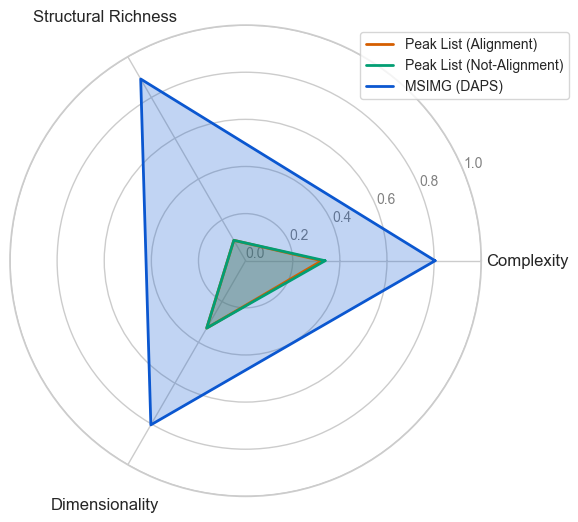


--- Running Analysis: Inter-Channel Information Redundancy ---
Need 57 / 64 principal components to explain 95% of variance.
Channel Non-Redundancy Score is: 0.891


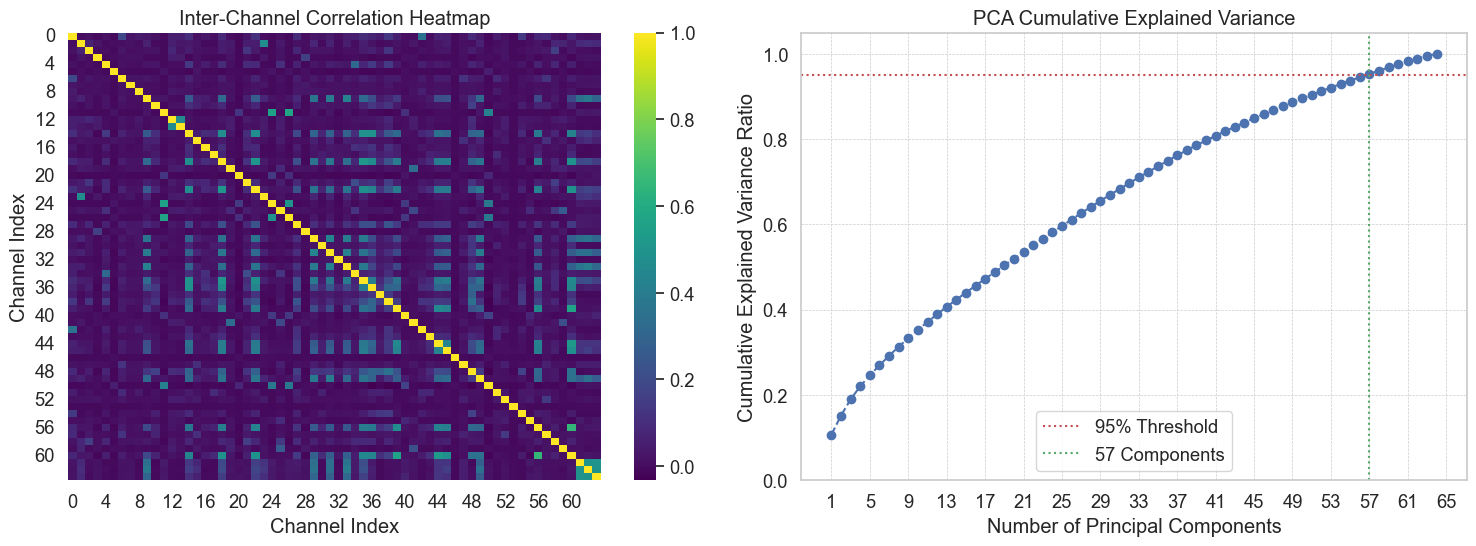

In [10]:
sample1_data_path = "../datasets/SPNS/PEAK_LIST/Aligned/SPNS_aligned_feature_list.csv"  # column 2JY1.mzML Peak height
sample2_data_path = "../datasets/SPNS/PEAK_LIST/Not-Aligned/SPNS/2JY1_peaks.csv"
sample3_data_path = "../datasets/SPNS/Entropy_64_DAPS_PATCH_224x224_WINDOW_100_INT_THR_0.1_DENS_THR_40_MIN_PKS_10_MZ_50.0-500.0_BIN_SIZE_0.1/SPNS/2JY1.npz"
sample1_data = load_ms_dataset(sample1_data_path, mz_min=50.0, mz_max=500.0, bin_size=0.1, align=True)
sample2_data = load_ms_dataset(sample2_data_path, mz_min=50.0, mz_max=500, bin_size=0.1, align=False)
# (64, 224, 224)
sample3_data = np.load(sample3_data_path)['patches']
samples_dict = {
    'Peak List (Alignment)': sample1_data,
    'Peak List (Not-Alignment)': sample2_data,
    'MSIMG (DAPS)': sample3_data
}
plot_radar_chart(samples_dict, normalization_method='sigmoid')
analyze_inter_channel_information_redundancy(sample3_data)